In [ ]:
from fsrs import Scheduler, Card, Rating, ReviewLog
from datetime import datetime, timezone, timedelta
import json

scheduler = Scheduler()
card = Card()

def format_json(json_string: str):
    formatted_json = json.dumps(json.loads(json_string), indent=4)
    return formatted_json

print(format_json(card.to_json()))

card, review_log = scheduler.review_card(card, Rating.Good)

print(format_json(card.to_json()))



{
    "card_id": 1771131276334,
    "state": 1,
    "step": 0,
    "stability": null,
    "difficulty": null,
    "due": "2026-02-15T04:54:36.335688+00:00",
    "last_review": null
}
{
    "card_id": 1771131276334,
    "state": 1,
    "step": 1,
    "stability": 2.3065,
    "difficulty": 2.118103970459016,
    "due": "2026-02-15T05:04:36.336185+00:00",
    "last_review": "2026-02-15T04:54:36.336185+00:00"
}
{
    "card_id": 1771131276334,
    "rating": 3,
    "review_datetime": "2026-02-15T04:54:36.336185+00:00",
    "review_duration": null
}


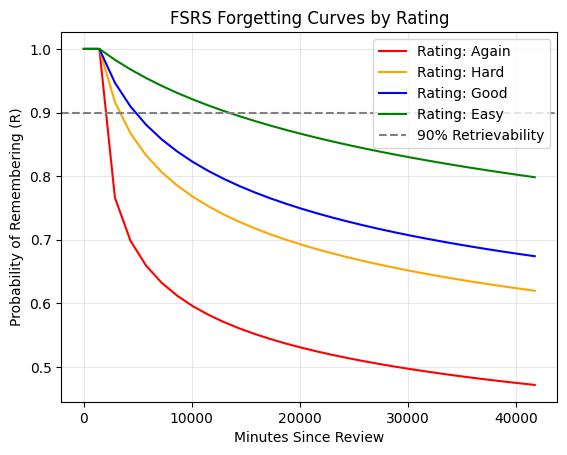

In [ ]:
from fsrs import Scheduler, Card, Rating
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

# 1. Initialize scheduler (disable learning steps to see Review state decay)
scheduler = Scheduler()
now = datetime.now(timezone.utc)
day_in_minutes = [60 * 24 * i for i in range(30)] # Extend to 30 days for better view

# 2. Iterate through each rating and plot its specific curve
ratings_to_plot = [Rating.Again, Rating.Hard, Rating.Good, Rating.Easy]
colors = ['red', 'orange', 'blue', 'green']

for rating, color in zip(ratings_to_plot, colors):
    # Start with a fresh card for each rating path
    card = Card()
    
    # Review the card with the specific rating
    card, _ = scheduler.review_card(card, rating)
    
    # Calculate retrievability over the timeline
    retrievabilities = [
        scheduler.get_card_retrievability(card)
        for m in day_in_minutes
    ]
    
    # Plot the line
    plt.plot(day_in_minutes, retrievabilities, label=f"Rating: {rating.name}", color=color)

# 3. Format and show the plot
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Retrievability')
plt.xlabel("Minutes Since Review")
plt.ylabel("Probability of Remembering (R)")
plt.title("FSRS Forgetting Curves by Rating")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [2]:
import string

translator = str.maketrans('', '', string.punctuation)
s1 = "What's your name?"
s1_clean = s1.translate(translator)
s1_clean

'Whats your name'